## Imports

In [1]:
from __future__ import annotations

from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import wandb

from walmart_forecasting.metrics import (
    weighted_mae,
)
from walmart_forecasting.paths import (
    PROJECT_ROOT,
    TABLES_DIR,
)
from walmart_forecasting.tracking import (
    setup_mlflow,
)


DOWNLOAD_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "comparison_inputs"
)

LIGHTGBM_DOWNLOAD_DIR = (
    DOWNLOAD_DIR
    / "lightgbm"
)

PATCHTST_DOWNLOAD_DIR = (
    DOWNLOAD_DIR
    / "patchtst"
)

for directory in [
    LIGHTGBM_DOWNLOAD_DIR,
    PATCHTST_DOWNLOAD_DIR,
    TABLES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download LightGBM predictions

In [2]:
LIGHTGBM_RUN_ID = (
    "4798f650278941f99d5e0e32a68fca3b"
)

LIGHTGBM_ARTIFACT_PATH = (
    "evaluation/"
    "holdout_predictions.csv"
)


setup_mlflow(
    experiment_name=(
        "LightGBM_Training"
    )
)

lightgbm_prediction_path = Path(
    mlflow.artifacts.download_artifacts(
        run_id=LIGHTGBM_RUN_ID,
        artifact_path=(
            LIGHTGBM_ARTIFACT_PATH
        ),
        dst_path=str(
            LIGHTGBM_DOWNLOAD_DIR
        ),
    )
)

if not lightgbm_prediction_path.exists():
    raise FileNotFoundError(
        "Downloaded LightGBM prediction "
        f"file was not found: "
        f"{lightgbm_prediction_path}"
    )

print(
    "LightGBM predictions:",
    lightgbm_prediction_path,
)

Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

LightGBM predictions: /home/xizusha/Documents/ML/walmart-store-sales-forecasting/artifacts/comparison_inputs/lightgbm/holdout_predictions.csv


## Download PatchTST predictions

In [3]:
WANDB_ENTITY = (
    "lkhiz23-free-university-of-tbilisi-"
)

WANDB_PROJECT = (
    "walmart-store-sales-forecasting"
)

PATCHTST_ARTIFACT = (
    f"{WANDB_ENTITY}/"
    f"{WANDB_PROJECT}/"
    "patchtst-final-model:v0"
)


wandb_api = wandb.Api()

patchtst_artifact = (
    wandb_api.artifact(
        PATCHTST_ARTIFACT
    )
)

patchtst_artifact_directory = Path(
    patchtst_artifact.download(
        root=str(
            PATCHTST_DOWNLOAD_DIR
        )
    )
)

patchtst_candidates = list(
    patchtst_artifact_directory.rglob(
        "holdout_predictions.csv"
    )
)

if len(patchtst_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one PatchTST "
        "holdout_predictions.csv, found "
        f"{len(patchtst_candidates)}."
    )

patchtst_prediction_path = (
    patchtst_candidates[0]
)

print(
    "PatchTST predictions:",
    patchtst_prediction_path,
)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb:   8 of 8 files downloaded.  


PatchTST predictions: /home/xizusha/Documents/ML/walmart-store-sales-forecasting/artifacts/comparison_inputs/patchtst/holdout_predictions.csv


## Load both files

In [4]:
lightgbm_predictions = pd.read_csv(
    lightgbm_prediction_path,
    parse_dates=["Date"],
)

patchtst_predictions = pd.read_csv(
    patchtst_prediction_path,
    parse_dates=["Date"],
)

print(
    "LightGBM rows:",
    len(lightgbm_predictions),
)

print(
    "PatchTST rows:",
    len(patchtst_predictions),
)

print(
    "\nLightGBM columns:"
)

print(
    lightgbm_predictions.columns.tolist()
)

print(
    "\nPatchTST columns:"
)

print(
    patchtst_predictions.columns.tolist()
)

LightGBM rows: 115588
PatchTST rows: 115588

LightGBM columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Prediction', 'AbsoluteError']

PatchTST columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'ModelPrediction', 'Prediction', 'AbsoluteError', 'forecast_block']


In [5]:
KEY_COLUMNS = [
    "Store",
    "Dept",
    "Date",
]

COMMON_REQUIRED_COLUMNS = {
    *KEY_COLUMNS,
    "Weekly_Sales",
    "IsHoliday",
    "Prediction",
}

missing_lightgbm = (
    COMMON_REQUIRED_COLUMNS
    - set(
        lightgbm_predictions.columns
    )
)

missing_patchtst = (
    COMMON_REQUIRED_COLUMNS
    - set(
        patchtst_predictions.columns
    )
)

if missing_lightgbm:
    raise ValueError(
        "LightGBM artifact is missing: "
        f"{sorted(missing_lightgbm)}"
    )

if missing_patchtst:
    raise ValueError(
        "PatchTST artifact is missing: "
        f"{sorted(missing_patchtst)}"
    )

if lightgbm_predictions.duplicated(
    KEY_COLUMNS
).any():
    raise ValueError(
        "Duplicate LightGBM keys."
    )

if patchtst_predictions.duplicated(
    KEY_COLUMNS
).any():
    raise ValueError(
        "Duplicate PatchTST keys."
    )


lightgbm_export = (
    lightgbm_predictions[
        [
            *KEY_COLUMNS,
            "Weekly_Sales",
            "IsHoliday",
            "Prediction",
        ]
    ]
    .rename(
        columns={
            "Prediction": (
                "LightGBMPrediction"
            ),
        }
    )
)

patchtst_columns = [
    *KEY_COLUMNS,
    "Weekly_Sales",
    "IsHoliday",
    "Prediction",
]

if (
    "ModelPrediction"
    in patchtst_predictions.columns
):
    patchtst_columns.append(
        "ModelPrediction"
    )

if (
    "forecast_block"
    in patchtst_predictions.columns
):
    patchtst_columns.append(
        "forecast_block"
    )

patchtst_export = (
    patchtst_predictions[
        patchtst_columns
    ]
    .rename(
        columns={
            "Prediction": (
                "PatchTSTPrediction"
            ),
            "ModelPrediction": (
                "PatchTSTRawPrediction"
            ),
        }
    )
)


merged = lightgbm_export.merge(
    patchtst_export,
    on=KEY_COLUMNS,
    how="inner",
    validate="one_to_one",
    suffixes=(
        "_lightgbm",
        "_patchtst",
    ),
)

if (
    len(merged)
    != len(lightgbm_export)
    or len(merged)
    != len(patchtst_export)
):
    raise ValueError(
        "LightGBM and PatchTST do not "
        "contain identical holdout rows."
    )

np.testing.assert_allclose(
    merged[
        "Weekly_Sales_lightgbm"
    ].to_numpy(),
    merged[
        "Weekly_Sales_patchtst"
    ].to_numpy(),
)

holiday_matches = (
    merged[
        "IsHoliday_lightgbm"
    ].astype(bool)
    == merged[
        "IsHoliday_patchtst"
    ].astype(bool)
)

if not holiday_matches.all():
    raise ValueError(
        "IsHoliday differs between "
        "the two artifacts."
    )

print(
    "Aligned rows:",
    len(merged),
)

print(
    "Holdout weeks:",
    merged["Date"].nunique(),
)

Aligned rows: 115588
Holdout weeks: 39


## Comparison frame

In [6]:
comparison = pd.DataFrame(
    {
        "Store": merged["Store"],
        "Dept": merged["Dept"],
        "Date": merged["Date"],
        "Weekly_Sales": merged[
            "Weekly_Sales_lightgbm"
        ],
        "IsHoliday": merged[
            "IsHoliday_lightgbm"
        ].astype(bool),
        "LightGBMPrediction": merged[
            "LightGBMPrediction"
        ],
        "PatchTSTPrediction": merged[
            "PatchTSTPrediction"
        ],
    }
)

if (
    "PatchTSTRawPrediction"
    in merged.columns
):
    comparison[
        "PatchTSTRawPrediction"
    ] = merged[
        "PatchTSTRawPrediction"
    ]

    comparison[
        "UsedPatchTST"
    ] = comparison[
        "PatchTSTRawPrediction"
    ].notna()
else:
    comparison[
        "UsedPatchTST"
    ] = True

if (
    "forecast_block"
    in merged.columns
):
    comparison[
        "ForecastBlock"
    ] = merged[
        "forecast_block"
    ]

comparison[
    "LightGBMAbsoluteError"
] = np.abs(
    comparison["Weekly_Sales"]
    - comparison[
        "LightGBMPrediction"
    ]
)

comparison[
    "PatchTSTAbsoluteError"
] = np.abs(
    comparison["Weekly_Sales"]
    - comparison[
        "PatchTSTPrediction"
    ]
)

comparison["Weight"] = np.where(
    comparison["IsHoliday"],
    5.0,
    1.0,
)

comparison[
    "LightGBMWeightedError"
] = (
    comparison["Weight"]
    * comparison[
        "LightGBMAbsoluteError"
    ]
)

comparison[
    "PatchTSTWeightedError"
] = (
    comparison["Weight"]
    * comparison[
        "PatchTSTAbsoluteError"
    ]
)

comparison.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,LightGBMPrediction,PatchTSTPrediction,PatchTSTRawPrediction,UsedPatchTST,ForecastBlock,LightGBMAbsoluteError,PatchTSTAbsoluteError,Weight,LightGBMWeightedError,PatchTSTWeightedError
0,1,1,2012-02-03,"23,510.4900",False,"21,280.0412","19,743.5780","19,743.5780",True,1,"2,230.4488","3,766.9120",1.0000,"2,230.4488","3,766.9120"
1,1,2,2012-02-03,"54,322.2400",False,"49,091.6221","47,513.6250","47,513.6250",True,1,"5,230.6179","6,808.6150",1.0000,"5,230.6179","6,808.6150"
2,1,3,2012-02-03,"12,485.7800",False,"11,371.6338","11,235.4420","11,235.4420",True,1,"1,114.1462","1,250.3380",1.0000,"1,114.1462","1,250.3380"
3,1,4,2012-02-03,"40,274.8300",False,"36,670.1307","37,837.5400","37,837.5400",True,1,"3,604.6993","2,437.2900",1.0000,"3,604.6993","2,437.2900"
4,1,5,2012-02-03,"28,307.4300",False,"29,979.9436","29,275.1290","29,275.1290",True,1,"1,672.5136",967.6990,1.0000,"1,672.5136",967.6990


## Verify original scores

In [7]:
lightgbm_wmae = weighted_mae(
    y_true=comparison[
        "Weekly_Sales"
    ],
    y_pred=comparison[
        "LightGBMPrediction"
    ],
    is_holiday=comparison[
        "IsHoliday"
    ],
)

patchtst_wmae = weighted_mae(
    y_true=comparison[
        "Weekly_Sales"
    ],
    y_pred=comparison[
        "PatchTSTPrediction"
    ],
    is_holiday=comparison[
        "IsHoliday"
    ],
)

relative_gap_pct = (
    100
    * (
        patchtst_wmae
        / lightgbm_wmae
        - 1
    )
)

print(
    "LightGBM WMAE:",
    lightgbm_wmae,
)

print(
    "PatchTST WMAE:",
    patchtst_wmae,
)

print(
    "PatchTST relative gap:",
    f"{relative_gap_pct:.3f}%",
)

print(
    "PatchTST neural coverage:",
    f"{comparison['UsedPatchTST'].mean():.2%}",
)

LightGBM WMAE: 1707.1122212088235
PatchTST WMAE: 1734.9984738167482
PatchTST relative gap: 1.634%
PatchTST neural coverage: 95.75%


## Save locally

In [8]:
lightgbm_export.to_parquet(
    TABLES_DIR
    / "lightgbm_holdout_predictions.parquet",
    index=False,
)

patchtst_export.to_parquet(
    TABLES_DIR
    / "patchtst_holdout_predictions.parquet",
    index=False,
)

comparison.to_parquet(
    TABLES_DIR
    / "lightgbm_vs_patchtst_rows.parquet",
    index=False,
)

print(
    "Comparison inputs saved."
)

Comparison inputs saved.


## Load comparison data

In [9]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from walmart_forecasting.metrics import (
    weighted_mae,
)
from walmart_forecasting.paths import (
    FIGURES_DIR,
    TABLES_DIR,
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)


comparison_path = (
    TABLES_DIR
    / "lightgbm_vs_patchtst_rows.parquet"
)

if not comparison_path.exists():
    raise FileNotFoundError(
        f"Comparison file not found: "
        f"{comparison_path}"
    )

comparison = pd.read_parquet(
    comparison_path
)

comparison["Date"] = pd.to_datetime(
    comparison["Date"]
)

comparison["IsHoliday"] = (
    comparison["IsHoliday"]
    .astype(bool)
)

required_columns = {
    "Store",
    "Dept",
    "Date",
    "Weekly_Sales",
    "IsHoliday",
    "LightGBMPrediction",
    "PatchTSTPrediction",
}

missing_columns = (
    required_columns
    - set(comparison.columns)
)

if missing_columns:
    raise ValueError(
        "Missing comparison columns: "
        f"{sorted(missing_columns)}"
    )

if "UsedPatchTST" not in comparison:
    comparison["UsedPatchTST"] = True

comparison["Weight"] = np.where(
    comparison["IsHoliday"],
    5.0,
    1.0,
)

comparison[
    "LightGBMAbsoluteError"
] = np.abs(
    comparison["Weekly_Sales"]
    - comparison[
        "LightGBMPrediction"
    ]
)

comparison[
    "PatchTSTAbsoluteError"
] = np.abs(
    comparison["Weekly_Sales"]
    - comparison[
        "PatchTSTPrediction"
    ]
)

comparison[
    "LightGBMWeightedError"
] = (
    comparison["Weight"]
    * comparison[
        "LightGBMAbsoluteError"
    ]
)

comparison[
    "PatchTSTWeightedError"
] = (
    comparison["Weight"]
    * comparison[
        "PatchTSTAbsoluteError"
    ]
)

print(
    "Rows:",
    len(comparison),
)

print(
    "Holdout weeks:",
    comparison["Date"].nunique(),
)

print(
    "PatchTST model coverage:",
    f"{comparison['UsedPatchTST'].mean():.2%}",
)

comparison.head()

Rows: 115588
Holdout weeks: 39
PatchTST model coverage: 95.75%


,Store,Dept,Date,Weekly_Sales,IsHoliday,LightGBMPrediction,PatchTSTPrediction,PatchTSTRawPrediction,UsedPatchTST,ForecastBlock,LightGBMAbsoluteError,PatchTSTAbsoluteError,Weight,LightGBMWeightedError,PatchTSTWeightedError
0,1,1,2012-02-03,"23,510.4900",False,"21,280.0412","19,743.5780","19,743.5780",True,1,"2,230.4488","3,766.9120",1.0000,"2,230.4488","3,766.9120"
1,1,2,2012-02-03,"54,322.2400",False,"49,091.6221","47,513.6250","47,513.6250",True,1,"5,230.6179","6,808.6150",1.0000,"5,230.6179","6,808.6150"
2,1,3,2012-02-03,"12,485.7800",False,"11,371.6338","11,235.4420","11,235.4420",True,1,"1,114.1462","1,250.3380",1.0000,"1,114.1462","1,250.3380"
3,1,4,2012-02-03,"40,274.8300",False,"36,670.1307","37,837.5400","37,837.5400",True,1,"3,604.6993","2,437.2900",1.0000,"3,604.6993","2,437.2900"
4,1,5,2012-02-03,"28,307.4300",False,"29,979.9436","29,275.1290","29,275.1290",True,1,"1,672.5136",967.6990,1.0000,"1,672.5136",967.6990


## Overall summary

In [10]:
def calculate_model_summary(
    frame: pd.DataFrame,
    prediction_column: str,
    model_name: str,
) -> dict:
    actual = frame[
        "Weekly_Sales"
    ].to_numpy(
        dtype=float
    )

    predicted = frame[
        prediction_column
    ].to_numpy(
        dtype=float
    )

    absolute_error = np.abs(
        actual - predicted
    )

    return {
        "model": model_name,
        "rows": len(frame),
        "wmae": weighted_mae(
            y_true=actual,
            y_pred=predicted,
            is_holiday=frame[
                "IsHoliday"
            ],
        ),
        "mae": float(
            absolute_error.mean()
        ),
        "rmse": float(
            np.sqrt(
                np.mean(
                    (
                        actual
                        - predicted
                    ) ** 2
                )
            )
        ),
        "mean_bias": float(
            np.mean(
                predicted - actual
            )
        ),
        "median_absolute_error": float(
            np.median(
                absolute_error
            )
        ),
        "p90_absolute_error": float(
            np.quantile(
                absolute_error,
                0.90,
            )
        ),
        "p95_absolute_error": float(
            np.quantile(
                absolute_error,
                0.95,
            )
        ),
        "p99_absolute_error": float(
            np.quantile(
                absolute_error,
                0.99,
            )
        ),
    }


overall_summary = pd.DataFrame(
    [
        calculate_model_summary(
            frame=comparison,
            prediction_column=(
                "LightGBMPrediction"
            ),
            model_name="LightGBM",
        ),
        calculate_model_summary(
            frame=comparison,
            prediction_column=(
                "PatchTSTPrediction"
            ),
            model_name="PatchTST",
        ),
    ]
)

best_wmae = overall_summary[
    "wmae"
].min()

overall_summary[
    "wmae_regret_pct"
] = (
    100
    * (
        overall_summary["wmae"]
        / best_wmae
        - 1
    )
)

overall_summary

,model,rows,wmae,mae,rmse,mean_bias,median_absolute_error,p90_absolute_error,p95_absolute_error,p99_absolute_error,wmae_regret_pct
0,LightGBM,115588,"1,707.1122","1,713.6278","3,646.4237",-291.1081,709.4103,"4,168.0022","6,564.3420","14,936.8539",0.0000
1,PatchTST,115588,"1,734.9985","1,725.4224","3,695.1199",-453.1777,708.4811,"4,279.9458","6,682.9142","14,678.2688",1.6335


## Comparison by 13-week forecast block

In [11]:
holdout_dates = (
    comparison["Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

if len(holdout_dates) != 39:
    raise ValueError(
        "Expected exactly 39 "
        "holdout dates."
    )

date_to_block = {
    date: index // 13 + 1
    for index, date in enumerate(
        holdout_dates
    )
}

comparison[
    "ForecastBlock"
] = comparison[
    "Date"
].map(
    date_to_block
)

block_rows = []

for block_number, group in (
    comparison.groupby(
        "ForecastBlock"
    )
):
    lightgbm_wmae = weighted_mae(
        y_true=group[
            "Weekly_Sales"
        ],
        y_pred=group[
            "LightGBMPrediction"
        ],
        is_holiday=group[
            "IsHoliday"
        ],
    )

    patchtst_wmae = weighted_mae(
        y_true=group[
            "Weekly_Sales"
        ],
        y_pred=group[
            "PatchTSTPrediction"
        ],
        is_holiday=group[
            "IsHoliday"
        ],
    )

    block_rows.append(
        {
            "forecast_block": int(
                block_number
            ),
            "start_date": group[
                "Date"
            ].min(),
            "end_date": group[
                "Date"
            ].max(),
            "weeks": group[
                "Date"
            ].nunique(),
            "lightgbm_wmae": (
                lightgbm_wmae
            ),
            "patchtst_wmae": (
                patchtst_wmae
            ),
            "absolute_difference": (
                patchtst_wmae
                - lightgbm_wmae
            ),
            "patchtst_regret_pct": (
                100
                * (
                    patchtst_wmae
                    / lightgbm_wmae
                    - 1
                )
            ),
            "winner": (
                "PatchTST"
                if patchtst_wmae
                < lightgbm_wmae
                else "LightGBM"
            ),
        }
    )

block_summary = pd.DataFrame(
    block_rows
)

block_summary

,forecast_block,start_date,end_date,weeks,lightgbm_wmae,patchtst_wmae,absolute_difference,patchtst_regret_pct,winner
0,1,2012-02-03,2012-04-27,13,"1,796.1555","1,780.7482",-15.4073,-0.8578,PatchTST
1,2,2012-05-04,2012-07-27,13,"1,616.7629","1,649.0544",32.2915,1.9973,LightGBM
2,3,2012-08-03,2012-10-26,13,"1,686.3451","1,754.4239",68.0788,4.0371,LightGBM


## Holiday vs no holiday

In [12]:
holiday_rows = []

for is_holiday, group in (
    comparison.groupby(
        "IsHoliday"
    )
):
    lightgbm_wmae = weighted_mae(
        y_true=group[
            "Weekly_Sales"
        ],
        y_pred=group[
            "LightGBMPrediction"
        ],
        is_holiday=group[
            "IsHoliday"
        ],
    )

    patchtst_wmae = weighted_mae(
        y_true=group[
            "Weekly_Sales"
        ],
        y_pred=group[
            "PatchTSTPrediction"
        ],
        is_holiday=group[
            "IsHoliday"
        ],
    )

    holiday_rows.append(
        {
            "segment": (
                "Holiday"
                if is_holiday
                else "Non-holiday"
            ),
            "rows": len(group),
            "dates": group[
                "Date"
            ].nunique(),
            "lightgbm_wmae": (
                lightgbm_wmae
            ),
            "patchtst_wmae": (
                patchtst_wmae
            ),
            "absolute_difference": (
                patchtst_wmae
                - lightgbm_wmae
            ),
            "patchtst_regret_pct": (
                100
                * (
                    patchtst_wmae
                    / lightgbm_wmae
                    - 1
                )
            ),
            "winner": (
                "PatchTST"
                if patchtst_wmae
                < lightgbm_wmae
                else "LightGBM"
            ),
        }
    )

holiday_summary = pd.DataFrame(
    holiday_rows
)

holiday_summary

,segment,rows,dates,lightgbm_wmae,patchtst_wmae,absolute_difference,patchtst_regret_pct,winner
0,Non-holiday,109621,37,"1,715.7000","1,722.3768",6.6768,0.3892,LightGBM
1,Holiday,5967,2,"1,675.5586","1,781.3734",105.8148,6.3152,LightGBM


In [24]:
holiday_gap_decomposition = (
    holiday_summary.copy()
)

total_weight = float(
    comparison["Weight"].sum()
)

segment_weights = (
    comparison
    .groupby(
        "IsHoliday"
    )["Weight"]
    .sum()
)

holiday_gap_decomposition[
    "weight_sum"
] = (
    holiday_gap_decomposition[
        "segment"
    ]
    .map(
        {
            "Holiday": float(
                segment_weights.loc[
                    True
                ]
            ),
            "Non-holiday": float(
                segment_weights.loc[
                    False
                ]
            ),
        }
    )
)

holiday_gap_decomposition[
    "metric_weight_share"
] = (
    holiday_gap_decomposition[
        "weight_sum"
    ]
    / total_weight
)

holiday_gap_decomposition[
    "contribution_to_total_gap"
] = (
    holiday_gap_decomposition[
        "absolute_difference"
    ]
    * holiday_gap_decomposition[
        "metric_weight_share"
    ]
)

total_gap = float(
    holiday_gap_decomposition[
        "contribution_to_total_gap"
    ].sum()
)

holiday_gap_decomposition[
    "share_of_total_gap"
] = (
    holiday_gap_decomposition[
        "contribution_to_total_gap"
    ]
    / total_gap
)

holiday_gap_decomposition

,segment,rows,dates,lightgbm_wmae,patchtst_wmae,absolute_difference,patchtst_regret_pct,winner,weight_sum,metric_weight_share,contribution_to_total_gap,share_of_total_gap
0,Non-holiday,109621,37,"1,715.7000","1,722.3768",6.6768,0.3892,LightGBM,"109,621.0000",0.7861,5.2484,0.1882
1,Holiday,5967,2,"1,675.5586","1,781.3734",105.8148,6.3152,LightGBM,"29,835.0000",0.2139,22.6378,0.8118


## Weekly scores

In [13]:
weekly_summary = (
    comparison
    .groupby(
        "Date",
        as_index=False,
    )
    .agg(
        IsHoliday=(
            "IsHoliday",
            "first",
        ),
        WeightSum=(
            "Weight",
            "sum",
        ),
        LightGBMWeightedErrorSum=(
            "LightGBMWeightedError",
            "sum",
        ),
        PatchTSTWeightedErrorSum=(
            "PatchTSTWeightedError",
            "sum",
        ),
    )
)

weekly_summary[
    "LightGBMWMAE"
] = (
    weekly_summary[
        "LightGBMWeightedErrorSum"
    ]
    / weekly_summary[
        "WeightSum"
    ]
)

weekly_summary[
    "PatchTSTWMAE"
] = (
    weekly_summary[
        "PatchTSTWeightedErrorSum"
    ]
    / weekly_summary[
        "WeightSum"
    ]
)

weekly_summary[
    "PatchTSTMinusLightGBM"
] = (
    weekly_summary[
        "PatchTSTWMAE"
    ]
    - weekly_summary[
        "LightGBMWMAE"
    ]
)

weekly_summary[
    "PatchTSTRegretPct"
] = (
    100
    * (
        weekly_summary[
            "PatchTSTWMAE"
        ]
        / weekly_summary[
            "LightGBMWMAE"
        ]
        - 1
    )
)

weekly_summary[
    "Winner"
] = np.select(
    [
        weekly_summary[
            "PatchTSTWMAE"
        ]
        < weekly_summary[
            "LightGBMWMAE"
        ],
        weekly_summary[
            "PatchTSTWMAE"
        ]
        > weekly_summary[
            "LightGBMWMAE"
        ],
    ],
    [
        "PatchTST",
        "LightGBM",
    ],
    default="Tie",
)

weekly_summary.head()

,Date,IsHoliday,WeightSum,LightGBMWeightedErrorSum,PatchTSTWeightedErrorSum,LightGBMWMAE,PatchTSTWMAE,PatchTSTMinusLightGBM,PatchTSTRegretPct,Winner
0,2012-02-03,False,"2,977.0000","4,782,779.5202","3,713,332.7520","1,606.5769","1,247.3405",-359.2364,-22.3604,PatchTST
1,2012-02-10,True,"15,005.0000","24,732,358.5496","25,709,208.4340","1,648.2745","1,713.3761",65.1016,3.9497,LightGBM
2,2012-02-17,False,"3,007.0000","5,152,914.1954","5,473,309.9047","1,713.6396","1,820.1895",106.5500,6.2178,LightGBM
3,2012-02-24,False,"2,961.0000","3,833,970.9286","4,029,804.9508","1,294.8230","1,360.9608",66.1378,5.1079,LightGBM
4,2012-03-02,False,"2,990.0000","4,505,910.1836","4,352,347.8725","1,506.9934","1,455.6347",-51.3586,-3.4080,PatchTST


## Weekly stability

In [14]:
def build_weekly_stability(
    model_name: str,
    score_column: str,
) -> dict:
    scores = weekly_summary[
        score_column
    ]

    return {
        "model": model_name,
        "weeks_won": int(
            (
                weekly_summary[
                    "Winner"
                ]
                == model_name
            ).sum()
        ),
        "weekly_win_rate": float(
            (
                weekly_summary[
                    "Winner"
                ]
                == model_name
            ).mean()
        ),
        "mean_weekly_wmae": float(
            scores.mean()
        ),
        "median_weekly_wmae": float(
            scores.median()
        ),
        "weekly_wmae_std": float(
            scores.std(ddof=0)
        ),
        "p90_weekly_wmae": float(
            scores.quantile(0.90)
        ),
        "p95_weekly_wmae": float(
            scores.quantile(0.95)
        ),
        "worst_week_wmae": float(
            scores.max()
        ),
    }


weekly_stability = pd.DataFrame(
    [
        build_weekly_stability(
            model_name="LightGBM",
            score_column=(
                "LightGBMWMAE"
            ),
        ),
        build_weekly_stability(
            model_name="PatchTST",
            score_column=(
                "PatchTSTWMAE"
            ),
        ),
    ]
)

weekly_stability

,model,weeks_won,weekly_win_rate,mean_weekly_wmae,median_weekly_wmae,weekly_wmae_std,p90_weekly_wmae,p95_weekly_wmae,worst_week_wmae
0,LightGBM,24,0.6154,"1,713.2117","1,647.4902",317.3930,"1,922.6509","2,120.5010","3,137.6833"
1,PatchTST,15,0.3846,"1,725.0939","1,664.1953",314.3606,"1,975.0207","2,061.3436","3,126.3399"


## Best and worst PatchTST weeks

In [15]:
print(
    "Weeks where LightGBM had "
    "the largest advantage:"
)

display(
    weekly_summary.sort_values(
        "PatchTSTMinusLightGBM",
        ascending=False,
    ).head(10)
)

print(
    "Weeks where PatchTST had "
    "the largest advantage:"
)

display(
    weekly_summary.sort_values(
        "PatchTSTMinusLightGBM",
        ascending=True,
    ).head(10)
)

Weeks where LightGBM had the largest advantage:


,Date,IsHoliday,WeightSum,LightGBMWeightedErrorSum,PatchTSTWeightedErrorSum,LightGBMWMAE,PatchTSTWMAE,PatchTSTMinusLightGBM,PatchTSTRegretPct,Winner
16,2012-05-25,False,"2,941.0000","4,947,877.9849","5,486,694.2211","1,682.3795","1,865.5880",183.2085,10.8898,LightGBM
31,2012-09-07,True,"14,830.0000","25,257,933.4174","27,438,067.1818","1,703.1648","1,850.1731",147.0083,8.6315,LightGBM
29,2012-08-24,False,"2,960.0000","5,563,265.9260","5,953,538.5896","1,879.4817","2,011.3306",131.8489,7.0152,LightGBM
17,2012-06-01,False,"2,943.0000","4,268,914.4491","4,656,778.3672","1,450.5316","1,582.3236",131.7920,9.0858,LightGBM
18,2012-06-08,False,"2,960.0000","5,075,477.8744","5,421,555.8867","1,714.6885","1,831.6067",116.9182,6.8186,LightGBM
2,2012-02-17,False,"3,007.0000","5,152,914.1954","5,473,309.9047","1,713.6396","1,820.1895",106.5500,6.2178,LightGBM
28,2012-08-17,False,"2,955.0000","4,835,637.6563","5,149,134.6410","1,636.4256","1,742.5160",106.0904,6.4831,LightGBM
22,2012-07-06,False,"2,961.0000","5,506,262.7531","5,805,623.7125","1,859.5957","1,960.6970",101.1013,5.4367,LightGBM
34,2012-09-28,False,"2,962.0000","4,821,028.2480","5,115,305.2865","1,627.6260","1,726.9768",99.3508,6.1040,LightGBM
35,2012-10-05,False,"2,976.0000","5,250,076.5495","5,538,338.5198","1,764.1386","1,861.0008",96.8622,5.4906,LightGBM


Weeks where PatchTST had the largest advantage:


,Date,IsHoliday,WeightSum,LightGBMWeightedErrorSum,PatchTSTWeightedErrorSum,LightGBMWMAE,PatchTSTWMAE,PatchTSTMinusLightGBM,PatchTSTRegretPct,Winner
0,2012-02-03,False,"2,977.0000","4,782,779.5202","3,713,332.7520","1,606.5769","1,247.3405",-359.2364,-22.3604,PatchTST
15,2012-05-18,False,"2,953.0000","5,576,263.3988","4,961,281.3150","1,888.3384","1,680.0817",-208.2567,-11.0286,PatchTST
5,2012-03-09,False,"2,974.0000","4,924,954.5529","4,348,275.4453","1,656.0035","1,462.0967",-193.9069,-11.7093,PatchTST
11,2012-04-20,False,"2,975.0000","7,779,561.1467","7,471,595.0267","2,614.9785","2,511.4605",-103.5180,-3.9587,PatchTST
37,2012-10-19,False,"2,950.0000","5,028,241.4465","4,761,849.8013","1,704.4886","1,614.1864",-90.3023,-5.2979,PatchTST
30,2012-08-31,False,"2,962.0000","6,101,426.3119","5,844,087.9166","2,059.9008","1,973.0209",-86.8799,-4.2177,PatchTST
12,2012-04-27,False,"2,954.0000","6,101,661.3140","5,857,841.3184","2,065.5590","1,983.0201",-82.5389,-3.9960,PatchTST
14,2012-05-11,False,"2,973.0000","4,723,137.0744","4,521,852.3470","1,588.6771","1,520.9729",-67.7042,-4.2617,PatchTST
4,2012-03-02,False,"2,990.0000","4,505,910.1836","4,352,347.8725","1,506.9934","1,455.6347",-51.3586,-3.4080,PatchTST
19,2012-06-15,False,"2,956.0000","4,540,083.5368","4,395,755.5077","1,535.8875","1,487.0621",-48.8254,-3.1790,PatchTST


## Pure PatchTST rows vs fallback rows

In [16]:
scope_masks = {
    "All rows": np.ones(
        len(comparison),
        dtype=bool,
    ),
    "PatchTST model rows": (
        comparison[
            "UsedPatchTST"
        ].to_numpy(
            dtype=bool
        )
    ),
    "PatchTST fallback rows": (
        ~comparison[
            "UsedPatchTST"
        ].to_numpy(
            dtype=bool
        )
    ),
}

scope_rows = []

for scope_name, mask in (
    scope_masks.items()
):
    scope_frame = comparison.loc[
        mask
    ]

    if scope_frame.empty:
        continue

    lightgbm_wmae = weighted_mae(
        y_true=scope_frame[
            "Weekly_Sales"
        ],
        y_pred=scope_frame[
            "LightGBMPrediction"
        ],
        is_holiday=scope_frame[
            "IsHoliday"
        ],
    )

    patchtst_wmae = weighted_mae(
        y_true=scope_frame[
            "Weekly_Sales"
        ],
        y_pred=scope_frame[
            "PatchTSTPrediction"
        ],
        is_holiday=scope_frame[
            "IsHoliday"
        ],
    )

    scope_rows.append(
        {
            "scope": scope_name,
            "rows": len(
                scope_frame
            ),
            "row_share": (
                len(scope_frame)
                / len(comparison)
            ),
            "lightgbm_wmae": (
                lightgbm_wmae
            ),
            "patchtst_wmae": (
                patchtst_wmae
            ),
            "absolute_difference": (
                patchtst_wmae
                - lightgbm_wmae
            ),
            "patchtst_regret_pct": (
                100
                * (
                    patchtst_wmae
                    / lightgbm_wmae
                    - 1
                )
            ),
            "winner": (
                "PatchTST"
                if patchtst_wmae
                < lightgbm_wmae
                else "LightGBM"
            ),
        }
    )

scope_summary = pd.DataFrame(
    scope_rows
)

scope_summary

,scope,rows,row_share,lightgbm_wmae,patchtst_wmae,absolute_difference,patchtst_regret_pct,winner
0,All rows,115588,1.0000,"1,707.1122","1,734.9985",27.8863,1.6335,LightGBM
1,PatchTST model rows,110680,0.9575,"1,753.9172","1,773.6827",19.7655,1.1269,LightGBM
2,PatchTST fallback rows,4908,0.0425,665.3189,873.9590,208.6400,31.3594,LightGBM


## Store-Department series win rate

In [17]:
series_summary = (
    comparison
    .groupby(
        [
            "Store",
            "Dept",
        ],
        as_index=False,
    )
    .agg(
        WeightSum=(
            "Weight",
            "sum",
        ),
        LightGBMWeightedErrorSum=(
            "LightGBMWeightedError",
            "sum",
        ),
        PatchTSTWeightedErrorSum=(
            "PatchTSTWeightedError",
            "sum",
        ),
        MeanSales=(
            "Weekly_Sales",
            "mean",
        ),
    )
)

series_summary[
    "LightGBMWMAE"
] = (
    series_summary[
        "LightGBMWeightedErrorSum"
    ]
    / series_summary[
        "WeightSum"
    ]
)

series_summary[
    "PatchTSTWMAE"
] = (
    series_summary[
        "PatchTSTWeightedErrorSum"
    ]
    / series_summary[
        "WeightSum"
    ]
)

series_summary[
    "Difference"
] = (
    series_summary[
        "PatchTSTWMAE"
    ]
    - series_summary[
        "LightGBMWMAE"
    ]
)

series_summary[
    "Winner"
] = np.select(
    [
        series_summary[
            "PatchTSTWMAE"
        ]
        < series_summary[
            "LightGBMWMAE"
        ],
        series_summary[
            "PatchTSTWMAE"
        ]
        > series_summary[
            "LightGBMWMAE"
        ],
    ],
    [
        "PatchTST",
        "LightGBM",
    ],
    default="Tie",
)

series_win_summary = (
    series_summary[
        "Winner"
    ]
    .value_counts()
    .rename_axis("model")
    .reset_index(
        name="series_won"
    )
)

series_win_summary[
    "series_win_rate"
] = (
    series_win_summary[
        "series_won"
    ]
    / len(series_summary)
)

series_win_summary

,model,series_won,series_win_rate
0,PatchTST,1820,0.5680
1,LightGBM,1384,0.4320


## Moving-block bootstrap function

In [18]:
def circular_moving_block_bootstrap(
    weekly_frame: pd.DataFrame,
    block_length: int,
    bootstrap_samples: int = 20_000,
    seed: int = 42,
    noninferiority_margin: float = 0.02,
) -> dict:
    if block_length <= 0:
        raise ValueError(
            "block_length must be "
            "positive."
        )

    rng = np.random.default_rng(
        seed
    )

    number_of_weeks = len(
        weekly_frame
    )

    number_of_blocks = int(
        np.ceil(
            number_of_weeks
            / block_length
        )
    )

    block_starts = rng.integers(
        low=0,
        high=number_of_weeks,
        size=(
            bootstrap_samples,
            number_of_blocks,
        ),
    )

    offsets = np.arange(
        block_length
    )

    sampled_indices = (
        (
            block_starts[
                :,
                :,
                None,
            ]
            + offsets[
                None,
                None,
                :,
            ]
        )
        % number_of_weeks
    )

    sampled_indices = (
        sampled_indices
        .reshape(
            bootstrap_samples,
            -1,
        )[
            :,
            :number_of_weeks,
        ]
    )

    weights = weekly_frame[
        "WeightSum"
    ].to_numpy(
        dtype=float
    )

    lightgbm_errors = weekly_frame[
        "LightGBMWeightedErrorSum"
    ].to_numpy(
        dtype=float
    )

    patchtst_errors = weekly_frame[
        "PatchTSTWeightedErrorSum"
    ].to_numpy(
        dtype=float
    )

    sampled_weights = (
        weights[
            sampled_indices
        ].sum(
            axis=1
        )
    )

    lightgbm_scores = (
        lightgbm_errors[
            sampled_indices
        ].sum(
            axis=1
        )
        / sampled_weights
    )

    patchtst_scores = (
        patchtst_errors[
            sampled_indices
        ].sum(
            axis=1
        )
        / sampled_weights
    )

    absolute_difference = (
        patchtst_scores
        - lightgbm_scores
    )

    relative_difference = (
        patchtst_scores
        / lightgbm_scores
        - 1
    )

    return {
        "block_length": (
            block_length
        ),
        "bootstrap_samples": (
            bootstrap_samples
        ),
        "difference_median": float(
            np.median(
                absolute_difference
            )
        ),
        "difference_ci_lower": float(
            np.quantile(
                absolute_difference,
                0.025,
            )
        ),
        "difference_ci_upper": float(
            np.quantile(
                absolute_difference,
                0.975,
            )
        ),
        "probability_patchtst_better": float(
            np.mean(
                absolute_difference
                < 0
            )
        ),
        "relative_gap_median_pct": float(
            100
            * np.median(
                relative_difference
            )
        ),
        "relative_gap_ci_lower_pct": float(
            100
            * np.quantile(
                relative_difference,
                0.025,
            )
        ),
        "relative_gap_ci_upper_pct": float(
            100
            * np.quantile(
                relative_difference,
                0.975,
            )
        ),
        "relative_gap_upper_95_pct": float(
            100
            * np.quantile(
                relative_difference,
                0.95,
            )
        ),
        "probability_within_2pct": float(
            np.mean(
                relative_difference
                < noninferiority_margin
            )
        ),
    }

In [19]:
bootstrap_results = pd.DataFrame(
    [
        circular_moving_block_bootstrap(
            weekly_frame=(
                weekly_summary
            ),
            block_length=(
                block_length
            ),
            bootstrap_samples=(
                20_000
            ),
            seed=42,
            noninferiority_margin=(
                0.02
            ),
        )
        for block_length in [
            2,
            4,
            6,
        ]
    ]
)

bootstrap_results

,block_length,bootstrap_samples,difference_median,difference_ci_lower,difference_ci_upper,probability_patchtst_better,relative_gap_median_pct,relative_gap_ci_lower_pct,relative_gap_ci_upper_pct,relative_gap_upper_95_pct,probability_within_2pct
0,2,20000,27.3180,-11.3124,62.4461,0.0828,1.6018,-0.6530,3.6990,3.3791,0.6421
1,4,20000,27.0562,-10.7801,64.1584,0.0847,1.5855,-0.6224,3.8118,3.4494,0.6421
2,6,20000,26.8229,-10.0045,65.9434,0.0838,1.5754,-0.5685,3.9312,3.5699,0.6337


In [20]:
NONINFERIORITY_MARGIN_PCT = 2.0

bootstrap_results[
    "noninferior_within_2pct"
] = (
    bootstrap_results[
        "relative_gap_upper_95_pct"
    ]
    < NONINFERIORITY_MARGIN_PCT
)

noninferiority_summary = (
    bootstrap_results[
        [
            "block_length",
            "difference_median",
            "difference_ci_lower",
            "difference_ci_upper",
            "probability_patchtst_better",
            "relative_gap_median_pct",
            "relative_gap_ci_lower_pct",
            "relative_gap_ci_upper_pct",
            "relative_gap_upper_95_pct",
            "probability_within_2pct",
            "noninferior_within_2pct",
        ]
    ]
)

noninferiority_summary

,block_length,difference_median,difference_ci_lower,difference_ci_upper,probability_patchtst_better,relative_gap_median_pct,relative_gap_ci_lower_pct,relative_gap_ci_upper_pct,relative_gap_upper_95_pct,probability_within_2pct,noninferior_within_2pct
0,2,27.3180,-11.3124,62.4461,0.0828,1.6018,-0.6530,3.6990,3.3791,0.6421,False
1,4,27.0562,-10.7801,64.1584,0.0847,1.5855,-0.6224,3.8118,3.4494,0.6421,False
2,6,26.8229,-10.0045,65.9434,0.0838,1.5754,-0.5685,3.9312,3.5699,0.6337,False


## Weekly WMAE

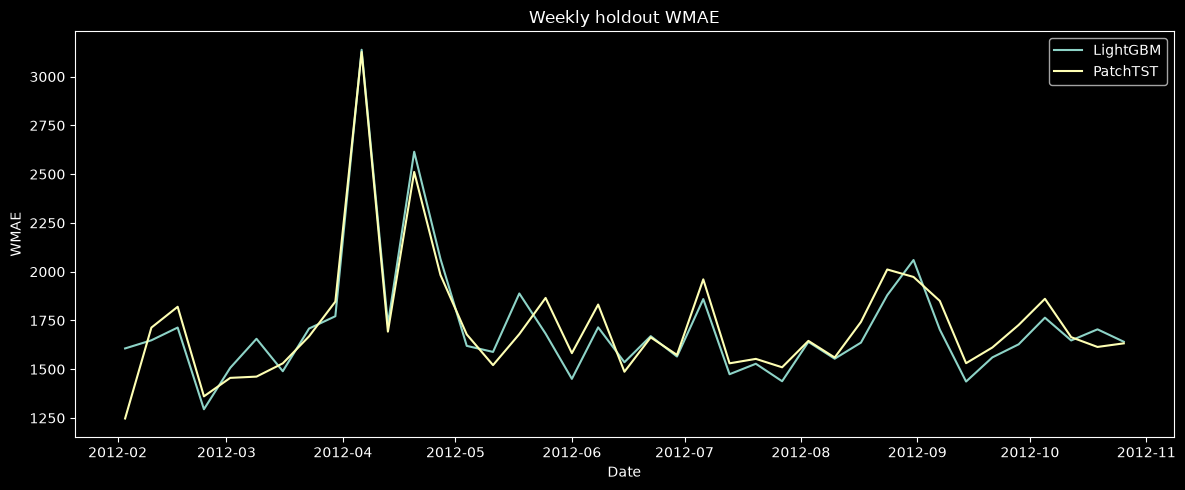

Saved: /home/xizusha/Documents/ML/walmart-store-sales-forecasting/reports/figures/lightgbm_vs_patchtst_weekly_wmae.png


In [21]:
figure, axis = plt.subplots(
    figsize=(12, 5)
)

axis.plot(
    weekly_summary["Date"],
    weekly_summary[
        "LightGBMWMAE"
    ],
    label="LightGBM",
)

axis.plot(
    weekly_summary["Date"],
    weekly_summary[
        "PatchTSTWMAE"
    ],
    label="PatchTST",
)

axis.set_title(
    "Weekly holdout WMAE"
)

axis.set_xlabel(
    "Date"
)

axis.set_ylabel(
    "WMAE"
)

axis.legend()

figure.tight_layout()

weekly_plot_path = (
    FIGURES_DIR
    / "lightgbm_vs_patchtst_weekly_wmae.png"
)

figure.savefig(
    weekly_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    weekly_plot_path,
)

## Forecast block

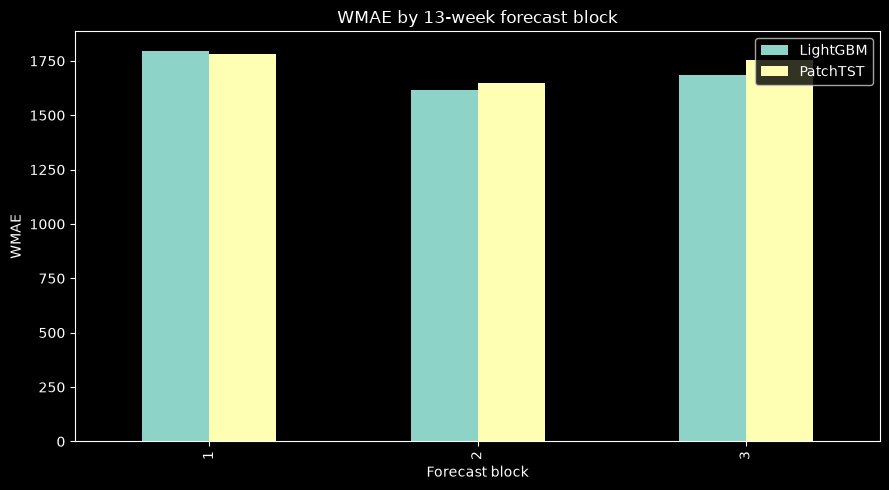

Saved: /home/xizusha/Documents/ML/walmart-store-sales-forecasting/reports/figures/lightgbm_vs_patchtst_blocks.png


In [22]:
block_plot_frame = (
    block_summary[
        [
            "forecast_block",
            "lightgbm_wmae",
            "patchtst_wmae",
        ]
    ]
    .set_index(
        "forecast_block"
    )
    .rename(
        columns={
            "lightgbm_wmae": (
                "LightGBM"
            ),
            "patchtst_wmae": (
                "PatchTST"
            ),
        }
    )
)

axis = block_plot_frame.plot(
    kind="bar",
    figsize=(9, 5),
)

axis.set_title(
    "WMAE by 13-week forecast block"
)

axis.set_xlabel(
    "Forecast block"
)

axis.set_ylabel(
    "WMAE"
)

figure = axis.get_figure()

figure.tight_layout()

block_plot_path = (
    FIGURES_DIR
    / "lightgbm_vs_patchtst_blocks.png"
)

figure.savefig(
    block_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    block_plot_path,
)

## Save all

In [23]:
overall_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_overall.csv",
    index=False,
)

block_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_blocks.csv",
    index=False,
)

holiday_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_holiday.csv",
    index=False,
)

weekly_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_weekly.csv",
    index=False,
)

weekly_stability.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_stability.csv",
    index=False,
)

scope_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_scope.csv",
    index=False,
)

series_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_series.csv",
    index=False,
)

series_win_summary.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_series_wins.csv",
    index=False,
)

bootstrap_results.to_csv(
    TABLES_DIR
    / "lightgbm_vs_patchtst_bootstrap.csv",
    index=False,
)

print(
    "All comparison tables saved."
)

All comparison tables saved.


## Exploratory ensemble models

In [25]:
ensemble_predictions = {
    "LightGBM": (
        comparison[
            "LightGBMPrediction"
        ].to_numpy()
    ),
    "PatchTST": (
        comparison[
            "PatchTSTPrediction"
        ].to_numpy()
    ),
    "HolidayGate": np.where(
        comparison["IsHoliday"],
        comparison[
            "LightGBMPrediction"
        ],
        comparison[
            "PatchTSTPrediction"
        ],
    ),
    "FallbackAware": np.where(
        comparison[
            "UsedPatchTST"
        ],
        comparison[
            "PatchTSTPrediction"
        ],
        comparison[
            "LightGBMPrediction"
        ],
    ),
    "EqualBlend": (
        0.5
        * comparison[
            "LightGBMPrediction"
        ]
        + 0.5
        * comparison[
            "PatchTSTPrediction"
        ]
    ),
}


ensemble_rows = []

for model_name, predictions in (
    ensemble_predictions.items()
):
    ensemble_rows.append(
        {
            "model": model_name,
            "wmae": weighted_mae(
                y_true=comparison[
                    "Weekly_Sales"
                ],
                y_pred=predictions,
                is_holiday=comparison[
                    "IsHoliday"
                ],
            ),
            "mae": float(
                np.mean(
                    np.abs(
                        comparison[
                            "Weekly_Sales"
                        ].to_numpy()
                        - predictions
                    )
                )
            ),
        }
    )

ensemble_summary = (
    pd.DataFrame(
        ensemble_rows
    )
    .sort_values("wmae")
    .reset_index(drop=True)
)

ensemble_summary

,model,wmae,mae
0,EqualBlend,"1,621.2650","1,622.9373"
1,LightGBM,"1,707.1122","1,713.6278"
2,HolidayGate,"1,712.3606","1,719.9599"
3,FallbackAware,"1,726.0279","1,715.5621"
4,PatchTST,"1,734.9985","1,725.4224"


In [33]:
lightgbm_reference_wmae = float(
    overall_summary.loc[
        overall_summary["model"]
        == "LightGBM",
        "wmae",
    ].iloc[0]
)

patchtst_reference_wmae = float(
    overall_summary.loc[
        overall_summary["model"]
        == "PatchTST",
        "wmae",
    ].iloc[0]
)

print(
    "Equal blend WMAE:",
    equal_blend_wmae,
)

print(
    "Equal blend MAE:",
    equal_blend_mae,
)

print(
    "Improvement over LightGBM:",
    f"{100 * (1 - equal_blend_wmae / lightgbm_reference_wmae):.2f}%",
)

print(
    "Improvement over PatchTST:",
    f"{100 * (1 - equal_blend_wmae / patchtst_reference_wmae):.2f}%",
)

Equal blend WMAE: 1621.2649723733687
Equal blend MAE: 1622.9373479621147
Improvement over LightGBM: 5.03%
Improvement over PatchTST: 6.56%


In [27]:
ensemble_block_rows = []

for block_number, group in (
    comparison.groupby(
        "ForecastBlock"
    )
):
    model_predictions = {
        "LightGBM": (
            group[
                "LightGBMPrediction"
            ]
        ),
        "PatchTST": (
            group[
                "PatchTSTPrediction"
            ]
        ),
        "EqualBlend": (
            group[
                "EqualBlendPrediction"
            ]
        ),
    }

    for model_name, predictions in (
        model_predictions.items()
    ):
        ensemble_block_rows.append(
            {
                "forecast_block": int(
                    block_number
                ),
                "model": model_name,
                "start_date": group[
                    "Date"
                ].min(),
                "end_date": group[
                    "Date"
                ].max(),
                "wmae": weighted_mae(
                    y_true=group[
                        "Weekly_Sales"
                    ],
                    y_pred=predictions,
                    is_holiday=group[
                        "IsHoliday"
                    ],
                ),
            }
        )

ensemble_block_summary = (
    pd.DataFrame(
        ensemble_block_rows
    )
    .pivot(
        index=[
            "forecast_block",
            "start_date",
            "end_date",
        ],
        columns="model",
        values="wmae",
    )
    .reset_index()
)

ensemble_block_summary[
    "BlendVsLightGBMImprovementPct"
] = (
    100
    * (
        1
        - ensemble_block_summary[
            "EqualBlend"
        ]
        / ensemble_block_summary[
            "LightGBM"
        ]
    )
)

ensemble_block_summary

model,forecast_block,start_date,end_date,EqualBlend,LightGBM,PatchTST,BlendVsLightGBMImprovementPct
0,1,2012-02-03,2012-04-27,"1,686.6817","1,796.1555","1,780.7482",6.0949
1,2,2012-05-04,2012-07-27,"1,544.0011","1,616.7629","1,649.0544",4.5005
2,3,2012-08-03,2012-10-26,"1,614.2986","1,686.3451","1,754.4239",4.2723


In [28]:
ensemble_segment_rows = []

for is_holiday, group in (
    comparison.groupby(
        "IsHoliday"
    )
):
    model_predictions = {
        "LightGBM": (
            group[
                "LightGBMPrediction"
            ]
        ),
        "PatchTST": (
            group[
                "PatchTSTPrediction"
            ]
        ),
        "EqualBlend": (
            group[
                "EqualBlendPrediction"
            ]
        ),
    }

    for model_name, predictions in (
        model_predictions.items()
    ):
        ensemble_segment_rows.append(
            {
                "segment": (
                    "Holiday"
                    if is_holiday
                    else "Non-holiday"
                ),
                "model": model_name,
                "rows": len(group),
                "dates": group[
                    "Date"
                ].nunique(),
                "wmae": weighted_mae(
                    y_true=group[
                        "Weekly_Sales"
                    ],
                    y_pred=predictions,
                    is_holiday=group[
                        "IsHoliday"
                    ],
                ),
            }
        )

ensemble_segment_summary = (
    pd.DataFrame(
        ensemble_segment_rows
    )
    .pivot(
        index=[
            "segment",
            "rows",
            "dates",
        ],
        columns="model",
        values="wmae",
    )
    .reset_index()
)

ensemble_segment_summary[
    "BlendVsLightGBMImprovementPct"
] = (
    100
    * (
        1
        - ensemble_segment_summary[
            "EqualBlend"
        ]
        / ensemble_segment_summary[
            "LightGBM"
        ]
    )
)

ensemble_segment_summary

model,segment,rows,dates,EqualBlend,LightGBM,PatchTST,BlendVsLightGBMImprovementPct
0,Holiday,5967,2,"1,613.1660","1,675.5586","1,781.3734",3.7237
1,Non-holiday,109621,37,"1,623.4692","1,715.7000","1,722.3768",5.3757


In [29]:
ensemble_weekly_summary = (
    comparison
    .groupby(
        "Date",
        as_index=False,
    )
    .agg(
        WeightSum=(
            "Weight",
            "sum",
        ),
        LightGBMWeightedErrorSum=(
            "LightGBMWeightedError",
            "sum",
        ),
        PatchTSTWeightedErrorSum=(
            "PatchTSTWeightedError",
            "sum",
        ),
        EqualBlendWeightedErrorSum=(
            "EqualBlendWeightedError",
            "sum",
        ),
    )
)


def compare_blend_with_lightgbm(
    weekly_frame: pd.DataFrame,
    block_length: int,
    bootstrap_samples: int = 20_000,
    seed: int = 42,
) -> dict:
    rng = np.random.default_rng(
        seed
    )

    number_of_weeks = len(
        weekly_frame
    )

    number_of_blocks = int(
        np.ceil(
            number_of_weeks
            / block_length
        )
    )

    starts = rng.integers(
        0,
        number_of_weeks,
        size=(
            bootstrap_samples,
            number_of_blocks,
        ),
    )

    offsets = np.arange(
        block_length
    )

    sampled_indices = (
        (
            starts[
                :,
                :,
                None,
            ]
            + offsets[
                None,
                None,
                :,
            ]
        )
        % number_of_weeks
    )

    sampled_indices = (
        sampled_indices
        .reshape(
            bootstrap_samples,
            -1,
        )[
            :,
            :number_of_weeks,
        ]
    )

    weights = weekly_frame[
        "WeightSum"
    ].to_numpy(
        dtype=float
    )

    lightgbm_errors = weekly_frame[
        "LightGBMWeightedErrorSum"
    ].to_numpy(
        dtype=float
    )

    blend_errors = weekly_frame[
        "EqualBlendWeightedErrorSum"
    ].to_numpy(
        dtype=float
    )

    sampled_weights = (
        weights[
            sampled_indices
        ].sum(axis=1)
    )

    lightgbm_scores = (
        lightgbm_errors[
            sampled_indices
        ].sum(axis=1)
        / sampled_weights
    )

    blend_scores = (
        blend_errors[
            sampled_indices
        ].sum(axis=1)
        / sampled_weights
    )

    absolute_difference = (
        blend_scores
        - lightgbm_scores
    )

    relative_difference = (
        blend_scores
        / lightgbm_scores
        - 1
    )

    return {
        "block_length": (
            block_length
        ),
        "difference_median": float(
            np.median(
                absolute_difference
            )
        ),
        "difference_ci_lower": float(
            np.quantile(
                absolute_difference,
                0.025,
            )
        ),
        "difference_ci_upper": float(
            np.quantile(
                absolute_difference,
                0.975,
            )
        ),
        "probability_blend_better": float(
            np.mean(
                absolute_difference < 0
            )
        ),
        "improvement_median_pct": float(
            -100
            * np.median(
                relative_difference
            )
        ),
        "improvement_ci_lower_pct": float(
            -100
            * np.quantile(
                relative_difference,
                0.975,
            )
        ),
        "improvement_ci_upper_pct": float(
            -100
            * np.quantile(
                relative_difference,
                0.025,
            )
        ),
    }


ensemble_bootstrap_results = (
    pd.DataFrame(
        [
            compare_blend_with_lightgbm(
                weekly_frame=(
                    ensemble_weekly_summary
                ),
                block_length=(
                    block_length
                ),
                bootstrap_samples=(
                    20_000
                ),
                seed=42,
            )
            for block_length in [
                2,
                4,
                6,
            ]
        ]
    )
)

ensemble_bootstrap_results

,block_length,difference_median,difference_ci_lower,difference_ci_upper,probability_blend_better,improvement_median_pct,improvement_ci_lower_pct,improvement_ci_upper_pct
0,2,-85.7804,-104.0768,-69.6337,1.0000,5.0197,4.0448,6.1734
1,4,-85.7262,-104.6418,-68.2338,1.0000,5.0163,3.9523,6.2498
2,6,-85.5187,-105.3303,-67.1315,1.0000,4.9949,3.9026,6.2891


In [34]:
weight_sensitivity_rows = []

for lightgbm_weight in (
    np.linspace(
        0.0,
        1.0,
        21,
    )
):
    patchtst_weight = (
        1.0
        - lightgbm_weight
    )

    predictions = (
        lightgbm_weight
        * comparison[
            "LightGBMPrediction"
        ]
        + patchtst_weight
        * comparison[
            "PatchTSTPrediction"
        ]
    )

    score = weighted_mae(
        y_true=comparison[
            "Weekly_Sales"
        ],
        y_pred=predictions,
        is_holiday=comparison[
            "IsHoliday"
        ],
    )

    weight_sensitivity_rows.append(
        {
            "lightgbm_weight": (
                lightgbm_weight
            ),
            "patchtst_weight": (
                patchtst_weight
            ),
            "wmae": score,
            "beats_lightgbm": (
                score < lightgbm_reference_wmae
            ),
            "beats_patchtst": (
                score < patchtst_reference_wmae
            ),
        }
    )

weight_sensitivity = (
    pd.DataFrame(
        weight_sensitivity_rows
    )
)

weight_sensitivity

,lightgbm_weight,patchtst_weight,wmae,beats_lightgbm,beats_patchtst
0,0.0000,1.0000,"1,734.9985",False,False
1,0.0500,0.9500,"1,714.9615",False,True
2,0.1000,0.9000,"1,696.8553",True,True
3,0.1500,0.8500,"1,680.5753",True,True
4,0.2000,0.8000,"1,666.1299",True,True
5,0.2500,0.7500,"1,653.6347",True,True
6,0.3000,0.7000,"1,643.0493",True,True
7,0.3500,0.6500,"1,634.4120",True,True
8,0.4000,0.6000,"1,627.9417",True,True
9,0.4500,0.5500,"1,623.6426",True,True
